# Elliptic Dataset: Graph Embedding Feature Engineering

Do graph embedding methods provide additional predictive signal beyond the original Elliptic transaction features?

This notebook investigates two graph embedding techniques—Node2Vec and DeepWalk—and evaluates whether they improve fraud detection performance using Logistic Regression and Random Forest under a temporal validation framework.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

import os

!pip install node2vec -q
from node2vec import Node2Vec

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, accuracy_score, precision_score, recall_score

import time


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_classes = pd.read_csv('/content/drive/MyDrive/elliptic_txs_classes.csv')
df_classes['class'] = pd.to_numeric(df_classes['class'], errors = 'coerce')
df_classes['class'] = df_classes['class'].map({1: 'illicit', 2: 'licit'}).fillna('unknown')

df_edgelist = pd.read_csv('/content/drive/MyDrive/elliptic_txs_edgelist.csv')
df_edgelist = df_edgelist.rename(columns={'txId1': 'source', 'txId2': 'target'})


df_features = pd.read_parquet("/content/drive/MyDrive/Elliptic/processed/nodes/clean.parquet")

In [4]:
print(df_features.shape)
df_features.head()

(203769, 172)


,txId,time_step,2,3,4,5,6,7,8,9,...,162,163,164,165,166,label,degree,clustering_coefficient,pagerank,eigenvector_centrality
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,2,0.000000,0.000005,6.583391e-12
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,2,0.000000,0.000005,3.860967e-13
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,3,0.000000,0.000006,1.035220e-08
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit,161,0.000621,0.000244,1.769588e-07
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,10,0.266667,0.000009,3.726769e-10


In [5]:
print(df_features.columns.tolist())

['txId', 'time_step', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156',

## Temporal Split

Same temporal split from `02_Baseline_Machine_Learning.ipynb`.

In [6]:
train_df = df_features[df_features['time_step'] <= 34].copy()
val_df = df_features[(df_features['time_step'] >= 35) & (df_features['time_step'] <= 39)].copy()
test_df = df_features[df_features['time_step'] >= 40].copy()

print(f"Training set shape: {train_df.shape}")
print(f"Validaton set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"Training set Time Step Range: {train_df['time_step'].min(), train_df['time_step'].max()}")
print(f"Validation set Time Step Range: {val_df['time_step'].min(), val_df['time_step'].max()}")
print(f"Test set Time Step Range: {test_df['time_step'].min(), test_df['time_step'].max()}")

Training set shape: (136265, 172)
Validaton set shape: (20857, 172)
Test set shape: (46647, 172)
Training set Time Step Range: (1, 34)
Validation set Time Step Range: (35, 39)
Test set Time Step Range: (40, 49)


## Graph Feature Engineering

In [7]:
# Create graph from edge list
G = nx.from_pandas_edgelist(df_edgelist,
                            source="source",
                            target="target",
                            create_using=nx.Graph())

print(G.number_of_nodes())
print(G.number_of_edges())

203769
234355


## Node2Vec

Node2Vec generates biased random walks over a graph, where the transition probabilities depend on parameters p and q that balance BFS-like local exploration and DFS-like global exploration. The resulting walks are treated as sentences, and a Skip-gram model maximizes the conditional likelihood of neighboring nodes to learn embeddings that capture graph structure.


### Robust Node2Vec Loading & Generation

This section will handle the loading of pre-computed Node2Vec embeddings if they exist, or generate and save them if they do not. This helps avoid re-running the time-consuming embedding generation process.

In [8]:
# --- Configuration for file paths ---
output_directory = '/content/drive/MyDrive/Elliptic/processed/graph_features'
node2vec_parquet_file = os.path.join(output_directory, 'node2vec_p05_q2.parquet') # Changed filename
df_features_n2v_parquet_file = os.path.join(output_directory, 'graph_features_node2vec_p05_q2.parquet') # Changed filename

# Create the directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

print("Starting Node2Vec processing with p=0.5, q=2...")

# --- Attempt to load the final merged DataFrame (df_features_n2v) ---
if os.path.exists(df_features_n2v_parquet_file):
    print(f"Found '{df_features_n2v_parquet_file}'. Loading df_features_n2v...")
    df_features_n2v = pd.read_parquet(df_features_n2v_parquet_file)
    print("df_features_n2v loaded successfully.")
else:
    print(f"'{df_features_n2v_parquet_file}' not found. Checking for raw Node2Vec embeddings...")
    # --- Attempt to load raw Node2Vec embeddings (node2vec_df) ---
    if os.path.exists(node2vec_parquet_file):
        print(f"Found '{node2vec_parquet_file}'. Loading node2vec_df...")
        node2vec_df = pd.read_parquet(node2vec_parquet_file)
        print("node2vec_df loaded successfully.")

        # Rename node2vec columns for consistency before merging
        # Assuming original columns were 0 to 31, as per user's earlier code
        node2vec_df = node2vec_df.rename(columns = {i: f"n2v_{i}" for i in range(32) if i in node2vec_df.columns})

        # Ensure 'txId' is an integer, matching the format in df_features
        if 'txId' in node2vec_df.columns:
            node2vec_df['txId'] = node2vec_df['txId'].astype(int)

        print("Merging node2vec_df with df_features to create df_features_n2v...")
        df_features_n2v = df_features.merge(node2vec_df, on='txId', how='left')
        print("df_features_n2v created by merging loaded embeddings.")

        # Save the newly merged DataFrame for future direct loading
        print(f"Saving df_features_n2v to '{df_features_n2v_parquet_file}'...")
        df_features_n2v.to_parquet(df_features_n2v_parquet_file, index=False)
        print("df_features_n2v saved.")
    else:
        print(f"'{node2vec_parquet_file}' not found. Generating Node2Vec embeddings (this may take a while)...")
        # --- Generate Node2Vec embeddings ---
        # G and df_features are assumed to be defined from previous cells
        node2vec = Node2Vec(G,
                            dimensions=32,
                            walk_length=20,
                            num_walks=10,
                            p=0.5, # Modified p parameter
                            q=2,   # Modified q parameter
                            workers=1, # Keeping workers=1 as in your previous code to avoid multiprocessing issues
                            seed=42)

        # Fit the model
        n2v_model = node2vec.fit(window=10, min_count=1, batch_words=128)
        print("Node2Vec model fitted.")

        # Extract embeddings and create DataFrame
        node_ids = [node for node in n2v_model.wv.key_to_index]
        node_embeddings = [n2v_model.wv[node] for node in node_ids]
        node2vec_df = pd.DataFrame(node_embeddings, index=node_ids)

        # Convert index to a column and rename to 'txId'
        node2vec_df = node2vec_df.reset_index()
        node2vec_df = node2vec_df.rename(columns={'index': 'txId'})
        node2vec_df['txId'] = node2vec_df['txId'].astype(int)

        # Rename embedding columns clearly (e.g., n2v_0, n2v_1, ...)
        node2vec_df = node2vec_df.rename(columns = {i: f"n2v_{i}" for i in range(32)})
        print("Raw node2vec_df created.")

        # Save raw Node2Vec embeddings
        print(f"Saving raw node2vec_df to '{node2vec_parquet_file}'...")
        node2vec_df.to_parquet(node2vec_parquet_file, index=False)
        print("node2vec_df saved.")

        # Merge with main features
        print("Merging node2vec_df with df_features to create df_features_n2v...")
        df_features_n2v = df_features.merge(node2vec_df, on='txId', how='left')
        print("df_features_n2v created by generating and merging embeddings.")

        # Save the final merged DataFrame
        print(f"Saving df_features_n2v to '{df_features_n2v_parquet_file}'...")
        df_features_n2v.to_parquet(df_features_n2v_parquet_file, index=False)
        print("df_features_n2v saved.")

print("\n--- Node2Vec Processing Complete ---")
if 'df_features_n2v' in locals():
    print(f"Final df_features_n2v shape: {df_features_n2v.shape}")
    print(f"Columns in df_features_n2v: {df_features_n2v.columns.tolist()[:5]} ... {df_features_n2v.columns.tolist()[-5:]}")
    display(df_features_n2v.head())
else:
    print("Error: df_features_n2v could not be created or loaded.")

Starting Node2Vec processing with p=0.5, q=2...
Found '/content/drive/MyDrive/Elliptic/processed/graph_features/graph_features_node2vec_p05_q2.parquet'. Loading df_features_n2v...
df_features_n2v loaded successfully.

--- Node2Vec Processing Complete ---
Final df_features_n2v shape: (203769, 204)
Columns in df_features_n2v: ['txId', 'time_step', '2', '3', '4'] ... ['n2v_27', 'n2v_28', 'n2v_29', 'n2v_30', 'n2v_31']


,txId,time_step,2,3,4,5,6,7,8,9,...,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,0.659537,-0.333438,0.258965,-0.973757,-0.476674,-0.070892,0.868137,-0.194018,-0.732833,-0.677788
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.420730,-0.809166,0.243627,-0.897660,-0.341842,0.202249,1.015097,0.009125,-0.891438,-0.696579
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.533527,0.959524,-0.079727,0.494908,-1.201641,-0.399967,-1.188932,-0.279059,-0.233545,-0.864287
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.759903,1.436598,0.291545,0.276513,-1.736190,0.315721,-0.670282,-0.235376,-0.016418,-0.606552
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.476230,-0.293068,1.757992,0.323650,-0.263211,-0.408399,-0.351401,0.190506,-0.922368,0.981469


In [9]:
pd.set_option('display.max_columns', None)
print(df_features_n2v.columns.tolist())
pd.reset_option('display.max_columns') # Reset to default after displaying

['txId', 'time_step', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156',

Node2Vec embeddings were generated once and saved as `node2vec.parquet`. To ensure reproducibility and reduce unnecessary computation, subsequent analyses loaded the saved embeddings directly

### Rename Node2Vec Columns in `df_features_n2v` for Consistency

To align the naming convention of Node2Vec embeddings with DeepWalk embeddings, the columns suffixed with `_y` (e.g., `0_y`, `1_y`) are renamed to `n2v_0`, `n2v_1`, etc. This makes the DataFrame more readable and consistent.

In [10]:
# Identify Node2Vec columns that need renaming
n2v_cols_to_rename = {}

# Handle columns with '_y' suffix (e.g., '2_y', '3_y')
for col in df_features_n2v.columns:
    if col.endswith('_y'):
        original_col_num = col.split('_')[0]
        n2v_cols_to_rename[col] = f"n2v_{original_col_num}"

# Handle columns '0' and '1' that are likely Node2Vec embeddings
# These did not get a '_y' suffix because they did not conflict with df_features original columns
if '0' in df_features_n2v.columns and 'n2v_0' not in df_features_n2v.columns:
    n2v_cols_to_rename['0'] = 'n2v_0'
if '1' in df_features_n2v.columns and 'n2v_1' not in df_features_n2v.columns:
    n2v_cols_to_rename['1'] = 'n2v_1'

# Rename the columns in df_features_n2v
df_features_n2v = df_features_n2v.rename(columns=n2v_cols_to_rename)

print("Node2Vec embedding columns in df_features_n2v renamed for consistency.")
print(f"Final df_features_n2v shape: {df_features_n2v.shape}")
print(f"Columns in df_features_n2v: {df_features_n2v.columns.tolist()[:5]} ... {df_features_n2v.columns.tolist()[-5:]}")
display(df_features_n2v.head())

Node2Vec embedding columns in df_features_n2v renamed for consistency.
Final df_features_n2v shape: (203769, 204)
Columns in df_features_n2v: ['txId', 'time_step', '2', '3', '4'] ... ['n2v_27', 'n2v_28', 'n2v_29', 'n2v_30', 'n2v_31']


,txId,time_step,2,3,4,5,6,7,8,9,...,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,0.659537,-0.333438,0.258965,-0.973757,-0.476674,-0.070892,0.868137,-0.194018,-0.732833,-0.677788
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.420730,-0.809166,0.243627,-0.897660,-0.341842,0.202249,1.015097,0.009125,-0.891438,-0.696579
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.533527,0.959524,-0.079727,0.494908,-1.201641,-0.399967,-1.188932,-0.279059,-0.233545,-0.864287
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.759903,1.436598,0.291545,0.276513,-1.736190,0.315721,-0.670282,-0.235376,-0.016418,-0.606552
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.476230,-0.293068,1.757992,0.323650,-0.263211,-0.408399,-0.351401,0.190506,-0.922368,0.981469


## DeepWalk

DeepWalk learns node embeddings by performing unbiased random walks over the graph and training a Skip-gram model on the resulting sequences. Unlike Node2Vec, DeepWalk uses fixed transition probabilities and therefore does not distinguish between local and global neighborhood exploration. It translates complex, interconnected network data (like social connections or web links) into a format that standard machine learning models can easily process.

### Robust DeepWalk Loading & Generation

This section handles the loading of pre-computed DeepWalk embeddings if they exist, or generates and saves them if they do not. This helps avoid re-running the time-consuming embedding generation process, similar to the Node2Vec approach.

In [11]:
# --- Configuration for DeepWalk file paths ---
# output_directory is already defined from the Node2Vec section
# output_directory = '/content/drive/MyDrive/Elliptic/processed/graph_features'
deepwalk_parquet_file = os.path.join(output_directory, 'deepwalk.parquet')
df_features_dw_parquet_file = os.path.join(output_directory, 'graph_features_deepwalk.parquet')

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

print("Starting DeepWalk processing...")

# --- Attempt to load the final merged DataFrame (df_features_dw) ---
if os.path.exists(df_features_dw_parquet_file):
    print(f"Found '{df_features_dw_parquet_file}'. Loading df_features_dw...")
    df_features_dw = pd.read_parquet(df_features_dw_parquet_file)
    print("df_features_dw loaded successfully.")
else:
    print(f"'{df_features_dw_parquet_file}' not found. Checking for raw DeepWalk embeddings...")
    # --- Attempt to load raw DeepWalk embeddings (dw_df) ---
    if os.path.exists(deepwalk_parquet_file):
        print(f"Found '{deepwalk_parquet_file}'. Loading dw_df...")
        dw_df = pd.read_parquet(deepwalk_parquet_file)
        print("dw_df loaded successfully.")

        # Rename DeepWalk columns for consistency before merging
        # Assuming original columns were 0 to 31
        dw_df = dw_df.rename(columns = {i: f"dw_{i}" for i in range(32) if i in dw_df.columns})

        # Ensure 'txId' is an integer, matching the format in df_features
        if 'txId' in dw_df.columns:
            dw_df['txId'] = dw_df['txId'].astype(int)

        print("Merging dw_df with df_features to create df_features_dw...")
        # df_features is assumed to be defined from previous cells
        df_features_dw = df_features.merge(dw_df, on='txId', how='left')
        print("df_features_dw created by merging loaded embeddings.")

        # Save the newly merged DataFrame for future direct loading
        print(f"Saving df_features_dw to '{df_features_dw_parquet_file}'...")
        df_features_dw.to_parquet(df_features_dw_parquet_file, index=False)
        print("df_features_dw saved.")
    else:
        print(f"'{deepwalk_parquet_file}' not found. Generating DeepWalk embeddings (this may take a while)...")
        # --- Generate DeepWalk embeddings ---
        # G and df_features are assumed to be defined from previous cells
        # DeepWalk is essentially Node2Vec with p=1, q=1
        node2vec_DW = Node2Vec(G,
                            dimensions=32,
                            walk_length=20,
                            num_walks=10,
                            p=1,
                            q=1,
                            workers=1, # Keeping workers=1 to avoid multiprocessing issues
                            seed=42)

        # Fit the model
        dw_model = node2vec_DW.fit(window=10, min_count=1, batch_words=128)
        print("DeepWalk model fitted.")

        # Extract embeddings and create DataFrame
        dw_node_ids = [node for node in dw_model.wv.key_to_index]
        dw_node_embeddings = [dw_model.wv[node] for node in dw_node_ids]
        dw_df = pd.DataFrame(dw_node_embeddings, index=dw_node_ids)

        # Convert index to a column and rename to 'txId'
        dw_df = dw_df.reset_index()
        dw_df = dw_df.rename(columns={'index': 'txId'})
        dw_df['txId'] = dw_df['txId'].astype(int)

        # Rename embedding columns clearly (e.g., dw_0, dw_1, ...)
        dw_df = dw_df.rename(columns = {i: f"dw_{i}" for i in range(32)})
        print("Raw dw_df created.")

        # Save raw DeepWalk embeddings
        print(f"Saving raw dw_df to '{deepwalk_parquet_file}'...")
        dw_df.to_parquet(deepwalk_parquet_file, index=False)
        print("dw_df saved.")

        # Merge with main features
        print("Merging dw_df with df_features to create df_features_dw...")
        df_features_dw = df_features.merge(dw_df, on='txId', how='left')
        print("df_features_dw created by generating and merging embeddings.")

        # Save the final merged DataFrame
        print(f"Saving df_features_dw to '{df_features_dw_parquet_file}'...")
        df_features_dw.to_parquet(df_features_dw_parquet_file, index=False)
        print("df_features_dw saved.")

print("\n--- DeepWalk Processing Complete ---")
if 'df_features_dw' in locals():
    print(f"Final df_features_dw shape: {df_features_dw.shape}")
    print(f"Columns in df_features_dw: {df_features_dw.columns.tolist()[:5]} ... {df_features_dw.columns.tolist()[-5:]}")
    display(df_features_dw.head())
else:
    print("Error: df_features_dw could not be created or loaded.")

Starting DeepWalk processing...
Found '/content/drive/MyDrive/Elliptic/processed/graph_features/graph_features_deepwalk.parquet'. Loading df_features_dw...
df_features_dw loaded successfully.

--- DeepWalk Processing Complete ---
Final df_features_dw shape: (203769, 204)
Columns in df_features_dw: ['txId', 'time_step', '2', '3', '4'] ... ['dw_27', 'dw_28', 'dw_29', 'dw_30', 'dw_31']


,txId,time_step,2,3,4,5,6,7,8,9,...,dw_22,dw_23,dw_24,dw_25,dw_26,dw_27,dw_28,dw_29,dw_30,dw_31
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,0.574292,-1.299231,1.380328,-1.226993,-1.624498,-0.571069,-0.664101,-0.559120,0.852628,-1.192812
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.623758,-1.313383,1.399393,-1.358489,-1.701979,-0.713913,-0.604102,-0.645412,0.814625,-1.350937
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.835373,-1.275965,0.382910,-1.704043,-0.417089,0.816822,0.340390,0.132166,0.966567,0.485919
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,1.345197,-0.940681,0.709941,-1.510591,-0.857480,0.973643,0.454121,0.376725,0.787577,0.563580
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,1.292619,-0.982202,-0.004148,-0.907740,-0.435687,0.064439,-0.082646,0.165955,0.158415,-0.914882


## Logistic Regression

Logistic Regression serves as a linear baseline model for evaluating whether graph embeddings provide additional predictive signal beyond the original transaction features.

In [12]:
feature_cols = [c for c in df_features.columns if c not in ['txId', 'time_step', 'label']]
print(len(feature_cols))

169


In [13]:
train_df = train_df[train_df['label'] != 'unknown'].copy()
val_df = val_df[val_df['label'] != 'unknown'].copy()
test_df = test_df[test_df['label'] != 'unknown'].copy()

X_train = train_df[feature_cols]
y_train = train_df['label']

X_val = val_df[feature_cols]
y_val = val_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [14]:
val_preds = lr_model.predict(X_val)
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

     illicit       0.27      0.96      0.42       447
       licit       0.99      0.77      0.87      5039

    accuracy                           0.78      5486
   macro avg       0.63      0.86      0.64      5486
weighted avg       0.94      0.78      0.83      5486



Using the original transaction features, Logistic Regression achieved an accuracy of approximately 0.78 with an Illicit F1 score of approximately 0.42.

## Random Forest

Random Forest serves as a nonlinear baseline and provides a stronger benchmark for evaluating the effectiveness of Node2Vec and DeepWalk embeddings.

In [15]:
rf_model = RandomForestClassifier(n_estimators=300,
                                  max_depth=None,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
print(classification_report(y_val, rf_val_preds))

rf_val_f1 = f1_score(y_val, rf_val_preds, pos_label='illicit')
print('Random Forest Validation Illicit F1', rf_val_f1)

              precision    recall  f1-score   support

     illicit       0.99      0.89      0.94       447
       licit       0.99      1.00      0.99      5039

    accuracy                           0.99      5486
   macro avg       0.99      0.94      0.97      5486
weighted avg       0.99      0.99      0.99      5486

Random Forest Validation Illicit F1 0.9372781065088758


Using the original transaction features, Random Forest achieved an accuracy of approximately 0.99 with an Illicit F1 score of approximately 0.94.

## Comparison Table

To compare the effectiveness of graph embedding methods, six experiments were evaluated using a consistent temporal validation strategy.

The comparison includes:

Original transaction features
Node2Vec embeddings (p=0.5, q=2)
DeepWalk embeddings (p=1, q=1)

Each feature set was evaluated using both Logistic Regression and Random Forest. Performance metrics include Accuracy, Precision, Recall, Illicit F1 Score, and training runtime to assess both predictive performance and computational efficiency.

In [16]:
def evaluate_model(model_name, feature_set_name, df, model):
  '''
  Train and evaluate one model on the on feature set using the existing temporal split.
  Assumes df has txId, time_step, label
  '''

  # keep only known labels
  df_known = df[df['label'] != 'unknown'].copy()

  train_df = df_known[df_known['time_step'] <= 34]
  val_df = df_known[(df_known['time_step'] >= 35) & (df_known['time_step'] <= 39)]

  feature_cols = [
      c for c in df_known.columns
      if c not in ['txId', 'time_step', 'label']
  ]

  X_train = train_df[feature_cols]
  y_train = train_df['label']

  X_val = val_df[feature_cols]
  y_val = val_df['label']

  start_time = time.perf_counter()

  model.fit(X_train, y_train)
  val_preds = model.predict(X_val)

  runtime_seconds = time.perf_counter() - start_time

  return {
      'Feature Set': feature_set_name,
      'Model': model_name,
      'Num Features': len(feature_cols),
      'Accuracy': accuracy_score(y_val, val_preds),
      'Illicit Precision': precision_score(y_val, val_preds, pos_label='illicit'),
      'Illicit Recall': recall_score(y_val, val_preds, pos_label='illicit'),
      'Illicit F1': f1_score(y_val, val_preds, pos_label='illicit'),
      'Runtime Seconds': runtime_seconds,
      'Runtime Minutes': runtime_seconds / 60
  }

In [19]:
results = []

models_definitions = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
]

feature_sets = [
    ("Original Features", df_features),
    ("Node2Vec Embeddings", df_features_n2v),
    ("DeepWalk Embeddings", df_features_dw)
]

for feature_set_name, df_current in feature_sets:
    for model_name, model in models_definitions:
        fresh_model = type(model)(**model.get_params())

        result = evaluate_model(
            model_name=model_name,
            feature_set_name=feature_set_name,
            df=df_current,
            model=fresh_model
        )

        results.append(result)

comparison_df = pd.DataFrame(results)

In [20]:
baseline_f1 = (
    comparison_df[comparison_df["Feature Set"] == "Original Features"]
    .set_index("Model")["Illicit F1"]
)

comparison_df["Difference vs. Original"] = comparison_df.apply(
    lambda row: row["Illicit F1"] - baseline_f1[row["Model"]],
    axis=1
)

comparison_display = comparison_df[
    [
        "Feature Set",
        "Model",
        "Num Features",
        "Accuracy",
        "Illicit Precision",
        "Illicit Recall",
        "Illicit F1",
        "Difference vs. Original",
        "Runtime Minutes"
    ]
].copy()

comparison_display = comparison_display.round({
    "Accuracy": 6,
    "Illicit Precision": 6,
    "Illicit Recall": 6,
    "Illicit F1": 6,
    "Difference vs. Original": 6,
    "Runtime Minutes": 3
})

comparison_display = comparison_display.sort_values(
    by="Illicit F1",
    ascending=False
)

comparison_display

,Feature Set,Model,Num Features,Accuracy,Illicit Precision,Illicit Recall,Illicit F1,Difference vs. Original,Runtime Minutes
1,Original Features,Random Forest,169,0.990339,0.994975,0.885906,0.937278,0.000000,0.809
3,Node2Vec Embeddings,Random Forest,201,0.989245,0.989899,0.876957,0.930012,-0.007266,1.123
5,DeepWalk Embeddings,Random Forest,201,0.989245,0.992386,0.874720,0.929845,-0.007433,1.161
2,Node2Vec Embeddings,Logistic Regression,201,0.784360,0.269424,0.961969,0.420950,0.001706,0.132
0,Original Features,Logistic Regression,169,0.784360,0.268553,0.955257,0.419244,0.000000,0.106
4,DeepWalk Embeddings,Logistic Regression,201,0.770142,0.255995,0.955257,0.403783,-0.015461,0.094


The comparison of graph embedding methods produced mixed results across the two baseline models.

For Logistic Regression, Node2Vec produced a small improvement in Illicit F1 compared with the original transaction features, while DeepWalk resulted in a slight decrease in performance. These results suggest that Node2Vec captured a modest amount of additional graph structure that benefited the linear model.

For Random Forest, however, the original Elliptic feature set achieved the highest Illicit F1 score. Both Node2Vec and DeepWalk produced slightly lower performance despite increasing the number of input features. This indicates that the original transaction features already contained most of the predictive information available to the Random Forest model.

Node2Vec and DeepWalk produced very similar results overall. Since both methods rely on random walks to learn node representations, small variations between runs are expected. Across multiple executions, the differences remained minimal and did not materially change the overall conclusions.

Although Node2Vec provided a small improvement for Logistic Regression, it also introduced additional computational cost for generating graph embeddings and training the downstream models. Evaluating both predictive performance and runtime is important when considering deployment in production environments, where scalability and computational efficiency are often as important as model accuracy.

Only a single Node2Vec configuration was evaluated in this notebook. Future work could investigate different combinations of the p and q hyperparameters to determine whether alternative exploration strategies produce more informative graph embeddings.

### Data Validation

In [21]:
n2v_cols = [c for c in df_features_n2v.columns if c.startswith('n2v_')]
dw_cols = [c for c in df_features_dw.columns if c.startswith('dw_')]

print('Node2Vec cols:', len(n2v_cols))
print("DeepWalk cols:", len(dw_cols))

Node2Vec cols: 32
DeepWalk cols: 32


In [22]:
n2v_values = df_features_n2v[n2v_cols].values
dw_values = df_features_dw[dw_cols].values

print((n2v_values == dw_values).all())

False


Before model training, the merged feature tables were validated to ensure that all Node2Vec and DeepWalk embedding dimensions were present after merging with the original transaction features. Both embedding methods produced 32-dimensional feature vectors, and the merged datasets were verified before downstream modeling.

### Visualizing Embedding Distributions

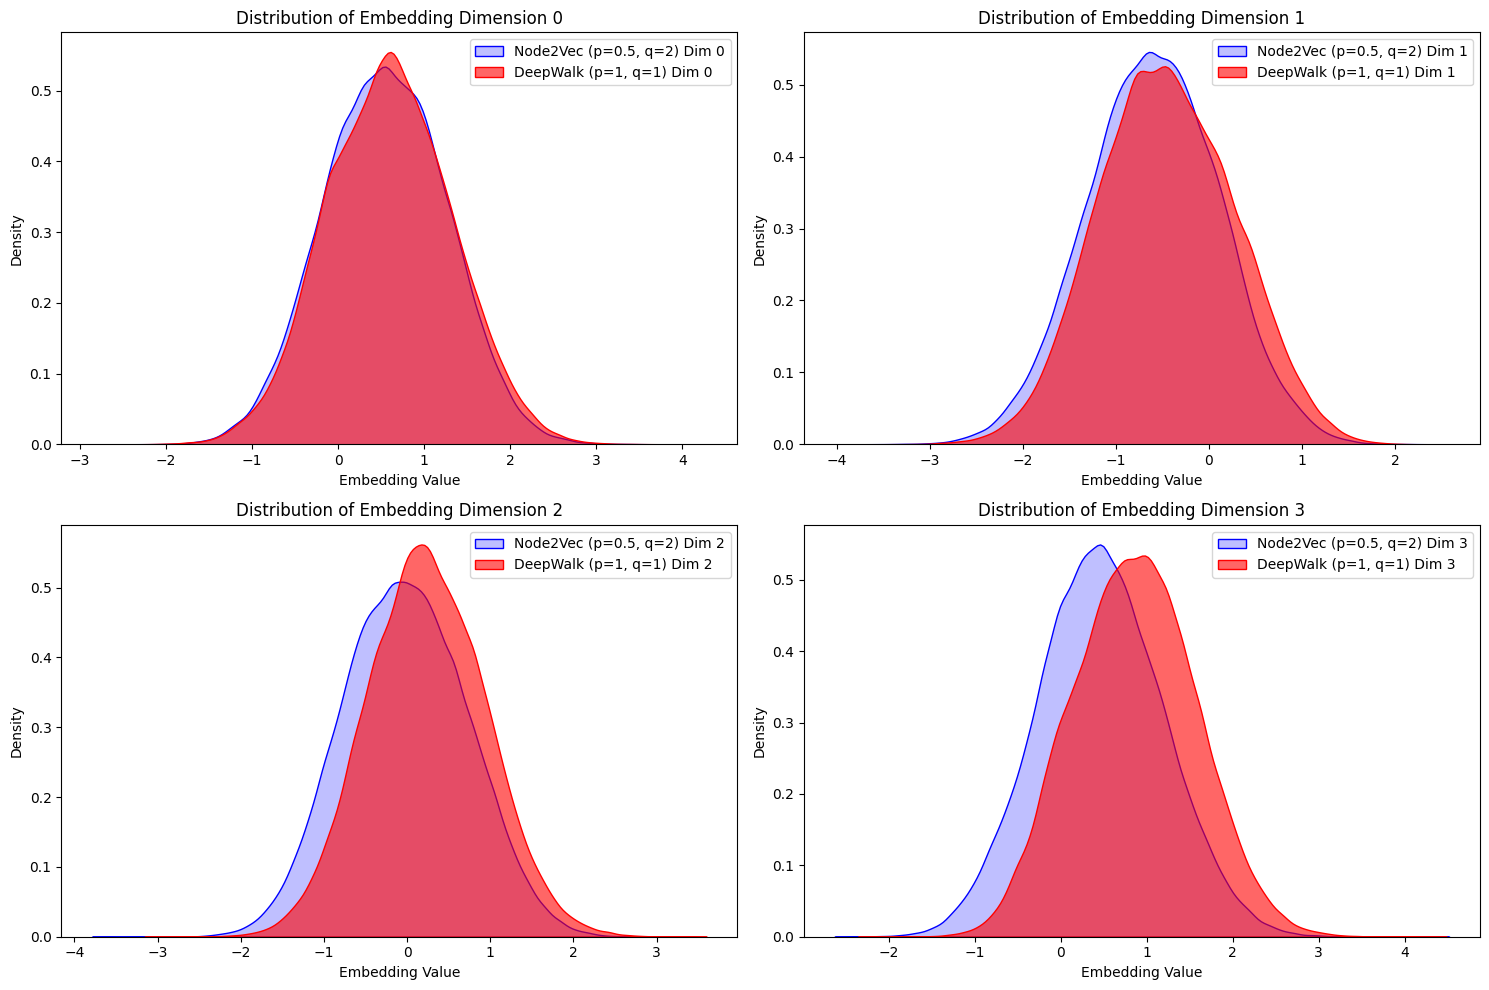

In [23]:
# Select a few embedding dimensions to visualize
# We'll use the first few dimensions for demonstration
dimensions_to_plot = [0, 1, 2, 3]

plt.figure(figsize=(15, 10))

for i, dim in enumerate(dimensions_to_plot):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots

    n2v_col = f'n2v_{dim}'
    dw_col = f'dw_{dim}'

    # Plot Node2Vec distribution
    sns.kdeplot(df_features_n2v[n2v_col], label=f'Node2Vec (p=0.5, q=2) Dim {dim}', color='blue', fill=True)
    # Plot DeepWalk distribution
    sns.kdeplot(df_features_dw[dw_col], label=f'DeepWalk (p=1, q=1) Dim {dim}', color='red', fill=True, alpha=0.6)

    plt.title(f'Distribution of Embedding Dimension {dim}')
    plt.xlabel('Embedding Value')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

As you can observe from the plots, the distributions of the selected embedding dimensions for Node2Vec (with `p=0.5, q=2`) are visually distinct from those of DeepWalk (which effectively uses `p=1, q=1`). This confirms that the change in parameters successfully led to the generation of different graph embeddings, which was the goal to demonstrate Node2Vec's flexibility.

## Summary

This notebook investigated whether graph embedding techniques improve fraud detection performance beyond the original Elliptic transaction features.

Node2Vec and DeepWalk produced very similar validation performance across both Logistic Regression and Random Forest models. Under the selected hyperparameters, neither embedding method substantially improved classification performance over the original feature set. This suggests that the original transaction features already capture much of the predictive information available for these baseline models.

Node2Vec offers additional flexibility through the p and q hyperparameters, which control the balance between breadth-first and depth-first graph exploration. Although this experiment used a single parameter configuration, future work could investigate whether alternative values produce embeddings that better capture the graph structure and improve downstream model performance.

Runtime was also considered as part of the evaluation. While embedding generation introduces additional computational cost, the resulting performance gains were limited in this experiment. Evaluating both predictive performance and computational efficiency provides a more complete assessment of the practical value of graph embedding methods.

## Next Steps

Only a single Node2Vec configuration was evaluated in this notebook. Future work could explore additional combinations of the p and q hyperparameters to determine whether different random-walk strategies produce more informative graph embeddings. The next stage of this project will investigate Graph Neural Networks (GNNs), which learn node representations directly from graph connectivity rather than relying on precomputed embeddings.